<Figure size 3000x1800 with 0 Axes>

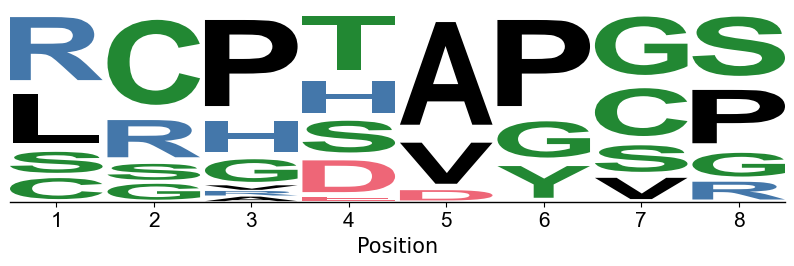

In [5]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("data/Excel/directed_evolution_assessment_library/enrichment_scores_with_amino_acid_sequences.xlsx") 

# Define Paul Tol's color scheme for each group
color_scheme = {
    'G': '#228833', 'S': '#228833', 'T': '#228833', 'Y': '#228833', 'C': '#228833',  # Polar (green)
    'Q': '#AA3377', 'N': '#AA3377',  # Neutral (purple)
    'K': '#4477AA', 'R': '#4477AA', 'H': '#4477AA',  # Basic (blue)
    'D': '#EE6677', 'E': '#EE6677',  # Acidic (red)
    'A': '#000000', 'V': '#000000', 'L': '#000000', 'I': '#000000', 'P': '#000000', 'W': '#000000', 'F': '#000000', 'M': '#000000'  # Hydrophobic (black)
}

# Filter rows with amino acids sequences of length 24
df = df[df['amino_acid_sequence'].str.len() == 8]

# Remove sequences with stop codons
df = df[~df['amino_acid_sequence'].str.contains('\*')]

AAs = 'ARNDCQEGHILKMFPSTWYV'
frequency_dict = {aa: [0] * 8 for aa in AAs}

# Calculate the frequency of each amino acid at each position
for sequence in df['amino_acid_sequence']:
    for pos, aa in enumerate(sequence):
        frequency_dict[aa][pos] += 1

# Convert the frequency dictionary to a DataFrame
frequency_df = pd.DataFrame(frequency_dict)

# Iterate through rows to get top 5 amino acids per position
top5_df = frequency_df.where(frequency_df.rank(axis=1, ascending=False) <= 5).fillna(0)

top5_df = top5_df.div(top5_df.sum(axis=1), axis=0)

# Create the motif-like plot
plt.figure(figsize=(10, 6), dpi=300)
logo = logomaker.Logo(top5_df, vpad=.2, shade_below=.5, fade_below=.5, font_name='Arial', color_scheme=color_scheme)
# Customize the plot
logo.style_spines(visible=False)
logo.style_spines(spines=['bottom'], visible=True)
logo.style_xticks(fmt='%d', anchor=0, fontsize=15)
#logo.ax.set_ylabel('Frequency', fontsize=18)
logo.ax.set_xlabel('Position', fontsize=15)
logo.ax.set_xticks(range(len(top5_df)))
logo.ax.set_xticklabels(range(1, len(top5_df) + 1), fontname='Arial', fontsize=15)
logo.ax.set_yticks([])
# Make the font size of the y-axis ticks larger
logo.ax.tick_params(axis='y', labelsize=15)
# Show the plot
plt.savefig('plots/figure_3b_i.png')
plt.show()

<Figure size 3000x1800 with 0 Axes>

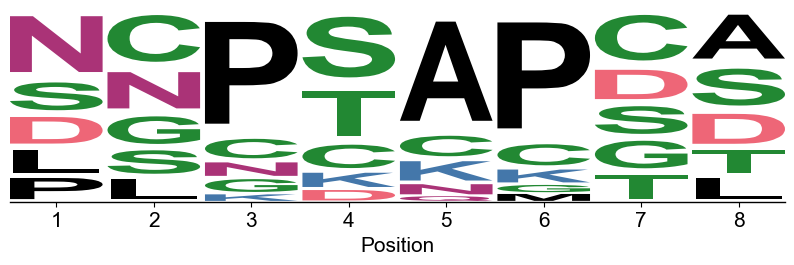

In [6]:
import logomaker
import matplotlib.pyplot as plt
import pandas as pd

df = pd.read_excel("data/Excel/ml_assessment_library/EVAAV/enrichment_score_with_amino_acid_sequence.xlsx") 

# Define Paul Tol's color scheme for each group
color_scheme = {
    'G': '#228833', 'S': '#228833', 'T': '#228833', 'Y': '#228833', 'C': '#228833',  # Polar (green)
    'Q': '#AA3377', 'N': '#AA3377',  # Neutral (purple)
    'K': '#4477AA', 'R': '#4477AA', 'H': '#4477AA',  # Basic (blue)
    'D': '#EE6677', 'E': '#EE6677',  # Acidic (red)
    'A': '#000000', 'V': '#000000', 'L': '#000000', 'I': '#000000', 'P': '#000000', 'W': '#000000', 'F': '#000000', 'M': '#000000'  # Hydrophobic (black)
}

# Filter rows with amino acids sequences of length 24
df = df[df['amino_acid_sequence'].str.len() == 8]

# Remove sequences with stop codons
df = df[~df['amino_acid_sequence'].str.contains('\*')]

AAs = 'ARNDCQEGHILKMFPSTWYV'
frequency_dict = {aa: [0] * 8 for aa in AAs}

# Calculate the frequency of each amino acid at each position
for sequence in df['amino_acid_sequence']:
    for pos, aa in enumerate(sequence):
        frequency_dict[aa][pos] += 1

# Convert the frequency dictionary to a DataFrame
frequency_df = pd.DataFrame(frequency_dict)

# Iterate through rows to get top 5 amino acids per position
top5_df = frequency_df.where(frequency_df.rank(axis=1, ascending=False) <= 5).fillna(0)

# Normalize top5_df
top5_df = top5_df.div(top5_df.sum(axis=1), axis=0)

plt.figure(figsize=(10, 6), dpi=300)
# make Figure and Axes objects
logo = logomaker.Logo(top5_df, vpad=.2, shade_below=.5, fade_below=.5, font_name='Arial', color_scheme=color_scheme)
# Customize the plot
logo.style_spines(visible=False)
logo.style_spines(spines=['bottom'], visible=True)
logo.style_xticks(fmt='%d', anchor=0, fontsize=5)
#logo.ax.set_ylabel('Frequency', fontsize=18)
logo.ax.set_xlabel('Position', fontsize=15, fontname='Arial')
logo.ax.set_xticks(range(len(top5_df)))
logo.ax.set_xticklabels(range(1, len(top5_df) + 1), fontname='Arial', fontsize=15)
logo.ax.set_yticks([])
# Make the font size of the y-axis ticks larger
logo.ax.tick_params(axis='y', labelsize=15)
# Show the plot
plt.savefig('plots/figure_3b_ii.png')
plt.show()